# Hierarchical Explanation Graph (HEG) Framework
## Causal Explainability for Hierarchical LLM-Based Multi-Agent Systems

This notebook implements the full HEG framework evaluated across **7 tasks** of varying complexity.

### Tasks
| # | Task | Complexity |
|---|------|------------|
| 1 | Summarize a topic | Simple |
| 2 | Answer a factual question | Simple |
| 3 | Write a short email | Simple |
| 4 | Plan a research project | Multi-step |
| 5 | Debug and fix a system architecture | Multi-step |
| 6 | Write a literature review | Multi-step |
| 7 | Design and launch a product roadmap | Multi-step |

### Pipeline
```
Orchestrator A (Normal)      Orchestrator B (Perturbation Controller)
       ↓                               ↓
Global Planner → S0          Perturb(S0) → cascade → Output_B0
Mid-Level Planner → S1       Perturb(S1) → cascade → Output_B1
Memory System → S2           Perturb(S2) → cascade → Output_B2
Research Agent → S3          Perturb(S3) → cascade → Output_B3
Analysis Agent → S4          Perturb(S4) → cascade → Output_B4
Critic Evaluator → S5        Perturb(S5) → cascade → Output_B5
       ↓                               ↓
  Output A               Causal Weights W_i = D_i / ΣD
                                       ↓
                          HEG + Discrepancy Report
```

## 0. Setup & Dependencies

In [ ]:
!pip install -q openai sentence-transformers numpy matplotlib networkx scikit-learn pandas seaborn

In [ ]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from dataclasses import dataclass, field
from typing import Optional
from copy import deepcopy

# ── API KEY ────────────────────────────────────────────────────────────────────
client  = OpenAI(api_key="-")
MODEL   = "gpt-4o"

# ── Embedding model (local, no API needed) ─────────────────────────────────────
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# ── Output directory ──────────────────────────────────────────────────────────
import os
os.makedirs("heg_outputs", exist_ok=True)

print("✅ Setup complete")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Setup complete


## 1. Data Structures

In [ ]:
@dataclass
class IntermediateState:
    """One layer's real output + self-explanation (intentional level)."""
    layer_name:  str
    output:      dict
    explanation: str
    layer_index: int

@dataclass
class PerturbationExperiment:
    """One perturbation experiment targeting a specific layer's true state."""
    target_layer:            str
    target_layer_index:      int
    original_state:          dict
    perturbed_state:         dict
    perturbation_description: str
    original_final_output:   str
    perturbed_final_output:  str
    divergence:              float = 0.0
    causal_weight:           float = 0.0

@dataclass
class TaskResult:
    """Full HEG result for one task."""
    task_id:     int
    task_label:  str
    complexity:  str   # 'simple' or 'multi-step'
    goal:        str
    states:      list
    experiments: list
    reports:     list
    output_a:    str

print("✅ Data structures defined")

✅ Data structures defined


## 2. LLM Helpers

In [ ]:
def call_llm(system_prompt: str, user_prompt: str, temperature: float = 0.3) -> str:
    response = client.chat.completions.create(
        model=MODEL,
        temperature=temperature,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt}
        ]
    )
    return response.choices[0].message.content.strip()


def call_llm_json_native(system_prompt: str, user_prompt: str, temperature: float = 0.3) -> dict:
    """
    Calls LLM with OpenAI native json_object mode — guarantees valid JSON.
    3-attempt fallback strategy for robustness.
    """
    def clean_and_parse(raw: str) -> dict:
        raw = raw.strip()
        if raw.startswith('```'):
            parts = raw.split('```')
            raw = parts[1] if len(parts) > 1 else raw
            if raw.startswith('json'):
                raw = raw[4:]
        raw = raw.strip().rstrip('`').strip()
        start, end = raw.find('{'), raw.rfind('}')
        if start != -1 and end != -1:
            raw = raw[start:end+1]
        return json.loads(raw)

    # Attempt 1: native json_object mode
    try:
        response = client.chat.completions.create(
            model=MODEL, temperature=temperature,
            response_format={'type': 'json_object'},
            messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user',   'content': user_prompt}
            ]
        )
        return json.loads(response.choices[0].message.content.strip())
    except Exception:
        pass

    # Attempt 2: normal call + clean parse
    raw = call_llm(system_prompt, user_prompt, temperature)
    try:
        return clean_and_parse(raw)
    except json.JSONDecodeError:
        pass

    # Attempt 3: repair
    repair = call_llm(
        'You are a JSON repair assistant. Output ONLY valid JSON.',
        f'Fix this broken JSON:\n{raw}\nOriginal task:\n{user_prompt}',
        temperature=0.0
    )
    return clean_and_parse(repair)


print("✅ LLM helpers ready")

✅ LLM helpers ready


## 3. Pipeline Layer Definitions (Orchestrator A)

In [ ]:
import json

# ── Global Planner ────────────────────────────────────────────────────────────
GLOBAL_PLANNER_SYSTEM = """You are the Global Planner of a hierarchical AI agent system.
Decompose the user goal into a high-level strategic plan.
Return JSON with exactly: {"output": {"goal": str, "constraints": [str], "success_criteria": [str], "strategic_priorities": [str]}, "explanation": str}"""

def run_global_planner(user_goal: str) -> IntermediateState:
    r = call_llm_json_native(GLOBAL_PLANNER_SYSTEM, f"User goal: {user_goal}")
    return IntermediateState("Global Planner", r["output"], r.get("explanation", ""), 0)


# ── Mid-Level Planner ─────────────────────────────────────────────────────────
MID_LEVEL_PLANNER_SYSTEM = """You are the Mid-Level Planner. Decompose the strategic plan into executable subtasks.
Return JSON with exactly: {"output": {"subtasks": [{"id": int, "name": str, "agent": str, "depends_on": [int]}], "workflow_order": [int], "estimated_complexity": str}, "explanation": str}"""

def run_mid_level_planner(s0: IntermediateState) -> IntermediateState:
    r = call_llm_json_native(MID_LEVEL_PLANNER_SYSTEM, f"Strategic plan: {json.dumps(s0.output)}")
    return IntermediateState("Mid-Level Planner", r["output"], r.get("explanation", ""), 1)


# ── Memory System ─────────────────────────────────────────────────────────────
MEMORY_SYSTEM = """You are the Memory System. Retrieve relevant memory chunks for the current task.
Return JSON with exactly: {"output": {"retrieved_chunks": [{"id": str, "content": str, "relevance_score": float}]}, "explanation": str}"""

def run_memory_system(s0: IntermediateState, s1: IntermediateState) -> IntermediateState:
    r = call_llm_json_native(MEMORY_SYSTEM, f"Plan: {json.dumps(s0.output)}\nSubtasks: {json.dumps(s1.output)}")
    return IntermediateState("Memory System", r["output"], r.get("explanation", ""), 2)


# ── Research Agent ────────────────────────────────────────────────────────────
RESEARCH_AGENT_SYSTEM = """You are the Research Agent. Collect relevant data and information for the subtasks.
Return JSON with exactly: {"output": {"collected_data": [{"source": str, "content": str, "reliability": str}], "tools_used": [str], "data_gaps": [str]}, "explanation": str}"""

def run_research_agent(s1: IntermediateState, s2: IntermediateState) -> IntermediateState:
    r = call_llm_json_native(RESEARCH_AGENT_SYSTEM, f"Subtasks: {json.dumps(s1.output)}\nMemory: {json.dumps(s2.output)}")
    return IntermediateState("Research Agent", r["output"], r.get("explanation", ""), 3)


# ── Analysis Agent ────────────────────────────────────────────────────────────
ANALYSIS_AGENT_SYSTEM = """You are the Analysis Agent. Process collected data and produce structured insights.
Return JSON with exactly: {"output": {"insights": [str], "conclusions": [str], "confidence": str, "recommended_action": str}, "explanation": str}"""

def run_analysis_agent(s2: IntermediateState, s3: IntermediateState) -> IntermediateState:
    r = call_llm_json_native(ANALYSIS_AGENT_SYSTEM, f"Memory: {json.dumps(s2.output)}\nData: {json.dumps(s3.output)}")
    return IntermediateState("Analysis Agent", r["output"], r.get("explanation", ""), 4)


# ── Critic Evaluator ──────────────────────────────────────────────────────────
CRITIC_EVALUATOR_SYSTEM = """You are the Critic Evaluator. Independently verify and score the pipeline output.
Return JSON with exactly: {"output": {"quality_score": float, "completeness_score": float, "faithfulness_score": float, "verdict": str, "final_answer": str, "issues_found": [str]}, "explanation": str}
All scores 0.0-1.0. verdict is accept|revise|reject."""

def run_critic_evaluator(s0, s1, s3, s4) -> IntermediateState:
    prompt = (f"Plan: {json.dumps(s0.output)}\nSubtasks: {json.dumps(s1.output)}"
              f"\nData: {json.dumps(s3.output)}\nAnalysis: {json.dumps(s4.output)}")
    r = call_llm_json_native(CRITIC_EVALUATOR_SYSTEM, prompt)
    return IntermediateState("Critic Evaluator", r["output"], r.get("explanation", ""), 5)


print("✅ All pipeline layers defined")

✅ All pipeline layers defined


## 4. Orchestrator A — Normal Pipeline

In [ ]:
def run_orchestrator_a(user_goal: str, verbose: bool = True) -> tuple:
    """
    Runs the full 6-layer hierarchical pipeline.
    Logs every intermediate state S0...S5.
    Each layer produces output + intentional self-explanation simultaneously.
    Returns: (states list, final answer string)
    """
    if verbose: print("  🔵 Orchestrator A running...")

    s0 = run_global_planner(user_goal)
    if verbose: print("    ✓ Global Planner")

    s1 = run_mid_level_planner(s0)
    if verbose: print("    ✓ Mid-Level Planner")

    s2 = run_memory_system(s0, s1)
    if verbose: print("    ✓ Memory System")

    s3 = run_research_agent(s1, s2)
    if verbose: print("    ✓ Research Agent")

    s4 = run_analysis_agent(s2, s3)
    if verbose: print("    ✓ Analysis Agent")

    s5 = run_critic_evaluator(s0, s1, s3, s4)
    if verbose: print("    ✓ Critic Evaluator")

    states  = [s0, s1, s2, s3, s4, s5]
    output_a = s5.output.get("final_answer", json.dumps(s5.output))
    if verbose: print("  ✅ Orchestrator A complete")
    return states, output_a

print("✅ Orchestrator A defined")

✅ Orchestrator A defined


## 5. Perturbation Engine

In [ ]:
PERTURBATION_ENGINE_SYSTEM = """You are the Perturbation Engine of a causal explainability framework.
Generate a MINIMAL, semantically meaningful perturbation of the given layer output.
RULES: smallest possible change, realistic, preserve structure.
Return JSON: {"perturbed_output": {...}, "perturbation_description": "one sentence"}"""

LAYER_PERTURBATION_INSTRUCTIONS = {
    "Global Planner":    "Remove ONE constraint OR change ONE success criterion OR alter ONE strategic priority. Do NOT change the goal.",
    "Mid-Level Planner": "Remove ONE subtask OR reorder two adjacent workflow steps OR change one agent assignment.",
    "Memory System":     "Remove the highest-relevance chunk OR replace one chunk's content with semantically different content.",
    "Research Agent":    "Remove one collected data item OR downgrade the highest-rated source reliability to 'low'.",
    "Analysis Agent":    "Remove one insight OR flip one conclusion to its opposite OR change confidence level.",
    "Critic Evaluator":  "Change verdict to 'revise' OR reduce quality_score by 0.3 OR add one critical issue."
}

def run_perturbation_engine(state: IntermediateState) -> tuple:
    instruction = LAYER_PERTURBATION_INSTRUCTIONS.get(state.layer_name, "Make a minimal meaningful change.")
    prompt = f"Layer: {state.layer_name}\nInstruction: {instruction}\nOutput to perturb:\n{json.dumps(state.output, indent=2)}"
    r = call_llm_json_native(PERTURBATION_ENGINE_SYSTEM, prompt, temperature=0.7)
    return r["perturbed_output"], r["perturbation_description"]

print("✅ Perturbation Engine defined")

✅ Perturbation Engine defined


## 6. Orchestrator B — Perturbation Controller

In [ ]:
def cascade_from(perturbed_state: dict, layer_index: int, original_states: list) -> str:
    """
    Takes a perturbed state at layer_index, reuses original upstream states,
    re-runs only downstream layers, returns final answer string.
    """
    working = [deepcopy(s.output) for s in original_states]
    working[layer_index] = perturbed_state

    def fake(idx):
        return IntermediateState(original_states[idx].layer_name, working[idx], "", idx)

    if layer_index <= 1:
        s2 = run_memory_system(fake(0), fake(1));   working[2] = s2.output
        s3 = run_research_agent(fake(1), fake(2));  working[3] = s3.output
        s4 = run_analysis_agent(fake(2), fake(3));  working[4] = s4.output
        s5 = run_critic_evaluator(fake(0), fake(1), fake(3), fake(4))
        return s5.output.get("final_answer", json.dumps(s5.output))

    elif layer_index == 2:
        s3 = run_research_agent(fake(1), fake(2));  working[3] = s3.output
        s4 = run_analysis_agent(fake(2), fake(3));  working[4] = s4.output
        s5 = run_critic_evaluator(fake(0), fake(1), fake(3), fake(4))
        return s5.output.get("final_answer", json.dumps(s5.output))

    elif layer_index == 3:
        s4 = run_analysis_agent(fake(2), fake(3));  working[4] = s4.output
        s5 = run_critic_evaluator(fake(0), fake(1), fake(3), fake(4))
        return s5.output.get("final_answer", json.dumps(s5.output))

    elif layer_index == 4:
        s5 = run_critic_evaluator(fake(0), fake(1), fake(3), fake(4))
        return s5.output.get("final_answer", json.dumps(s5.output))

    elif layer_index == 5:
        return perturbed_state.get("final_answer", json.dumps(perturbed_state))

    return ""


def run_orchestrator_b(states: list, output_a: str, verbose: bool = True) -> list:
    """
    For each true intermediate state S_i from Orchestrator A:
      1. Perturbation Engine generates perturbed S_i'
      2. Cascade normally from layer i+1 onward → Output_B_i
      3. Record PerturbationExperiment
    One experiment per layer — linear, not exponential.
    """
    if verbose: print("  🔴 Orchestrator B running...")
    experiments = []
    for state in states:
        if verbose: print(f"    ✓ Perturbing {state.layer_name}")
        perturbed_output, description = run_perturbation_engine(state)
        perturbed_final = cascade_from(perturbed_output, state.layer_index, states)
        experiments.append(PerturbationExperiment(
            target_layer=state.layer_name,
            target_layer_index=state.layer_index,
            original_state=state.output,
            perturbed_state=perturbed_output,
            perturbation_description=description,
            original_final_output=output_a,
            perturbed_final_output=perturbed_final
        ))
    if verbose: print("  ✅ Orchestrator B complete")
    return experiments

print("✅ Orchestrator B defined")

✅ Orchestrator B defined


## 7. Causal Weight Computation

For each experiment:
$$D_i = 1 - \cos(\text{embed}(\text{Output}_A),\; \text{embed}(\text{Output}_{B_i}))$$
$$W_i = \frac{D_i}{\sum_{j=1}^{n} D_j}$$

In [ ]:
def compute_causal_weights(experiments: list) -> list:
    orig_embs = embedder.encode([e.original_final_output  for e in experiments])
    pert_embs = embedder.encode([e.perturbed_final_output for e in experiments])

    divergences = []
    for i, exp in enumerate(experiments):
        sim = cosine_similarity(orig_embs[i].reshape(1,-1), pert_embs[i].reshape(1,-1))[0][0]
        experiments[i].divergence = float(1 - sim)
        divergences.append(experiments[i].divergence)

    total = sum(divergences) or 1.0
    for i in range(len(experiments)):
        experiments[i].causal_weight = divergences[i] / total

    return experiments

print("✅ Causal weight computation defined")

✅ Causal weight computation defined


## 8. Discrepancy Report — Intentional vs Causal

In [ ]:
DISCREPANCY_SYSTEM = """You compare an AI layer's self-explanation against its experimentally measured causal weight.
Determine if the self-explanation is faithful to the causal evidence or constitutes confabulation.
Return JSON: {"faithfulness": "faithful|partial|confabulated", "discrepancy_detected": bool, "analysis": str, "confabulation_evidence": str}"""

def generate_discrepancy_report(states: list, experiments: list) -> list:
    weight_map  = {e.target_layer: e.causal_weight for e in experiments}
    mean_weight = np.mean(list(weight_map.values()))
    reports = []
    for state in states:
        w = weight_map.get(state.layer_name, 0.0)
        rel = "above" if w > mean_weight else "below"
        pert_desc = next((e.perturbation_description for e in experiments if e.target_layer == state.layer_name), "N/A")
        prompt = (f"Layer: {state.layer_name}\n"
                  f"Self-explanation: {state.explanation}\n"
                  f"Causal weight W_i={w:.4f} ({rel} mean {mean_weight:.4f})\n"
                  f"Perturbation applied: {pert_desc}")
        r = call_llm_json_native(DISCREPANCY_SYSTEM, prompt)
        r.update({"layer": state.layer_name, "causal_weight": w, "intentional_explanation": state.explanation})
        reports.append(r)
    return reports

print("✅ Discrepancy report defined")

✅ Discrepancy report defined


## 9. Visualization Functions

In [ ]:
LAYER_NAMES = ["Global\nPlanner", "Mid-Level\nPlanner", "Memory\nSystem",
               "Research\nAgent", "Analysis\nAgent", "Critic\nEvaluator"]
LAYER_COLORS = ["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f","#edc948"]
GLOBAL_CAUSAL_WEIGHT_MAX_FOR_PLOTTING = 1.0 # Max theoretical causal weight is 1.0

def plot_heg(experiments: list, task_label: str, save_path: str = None):
    """HEG graph: node size/color = causal weight."""
    sorted_exp = sorted(experiments, key=lambda e: e.target_layer_index)
    names   = ["User\nGoal"] + [e.target_layer.replace(" ", "\n") for e in sorted_exp]

    # Collect weights and handle NaN values by replacing them with 0.0 for plotting
    raw_weights = [e.causal_weight for e in sorted_exp]
    processed_weights = [0.0 if np.isnan(w) else float(w) for w in raw_weights]
    weights = [0.0] + processed_weights # Add 0.0 for "User Goal" node

    G = nx.DiGraph()
    for n in names: G.add_node(n)
    for i in range(len(names)-1): G.add_edge(names[i], names[i+1])

    pos = {n: (0, -i) for i, n in enumerate(names)}

    # Use a global max for consistent color/size scaling across all tasks
    plot_max_w = GLOBAL_CAUSAL_WEIGHT_MAX_FOR_PLOTTING

    colors = [(0.95, 0.95, 0.95)] + [
        (1, max(0.0, min(1.0, 1-0.8*(w/plot_max_w))), max(0.0, min(1.0, 1-0.8*(w/plot_max_w)))) for w in weights[1:]
    ]
    sizes = [600] + [800 + 3500*(w/plot_max_w) for w in weights[1:]]
    labels = {names[0]: "User Goal"}
    for e, n in zip(sorted_exp, names[1:]):
        # Use original causal_weight for label display, processed for plotting (size/color)
        labels[n] = f"{n}\nW={e.causal_weight:.3f}"

    fig, ax = plt.subplots(figsize=(5, 10))
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="#444", arrows=True, arrowsize=18, width=2, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight="bold", ax=ax)
    ax.set_title(f"HEG — {task_label}", fontsize=11, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show(); plt.close()


def plot_causal_bar(experiments: list, task_label: str, save_path: str = None):
    """Horizontal bar chart of causal weights per layer."""
    sorted_exp = sorted(experiments, key=lambda e: e.causal_weight, reverse=True)
    names   = [e.target_layer for e in sorted_exp]

    # Collect weights and handle NaN values by replacing them with 0.0 for plotting
    raw_weights_bar = [e.causal_weight for e in sorted_exp]
    processed_weights_bar = [0.0 if np.isnan(w) else float(w) for w in raw_weights_bar]

    colors  = [LAYER_COLORS[e.target_layer_index] for e in sorted_exp]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(names[::-1], processed_weights_bar[::-1], color=colors[::-1], edgecolor="black", lw=0.5)
    for bar, w_plot in zip(bars, processed_weights_bar[::-1]):
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                f"{w_plot:.3f}", va="center", fontsize=9, fontweight="bold")
    ax.axvline(1/6, color="gray", ls="--", lw=1, label="Uniform baseline (1/6)")
    ax.set_xlabel("Causal Weight W_i");

    max_w_bar = max(processed_weights_bar) if processed_weights_bar else 0.0
    ax.set_xlim(0, max_w_bar * 1.25 if max_w_bar > 0 else 0.1)

    ax.set_title(f"Causal Attribution — {task_label}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show(); plt.close()


def plot_faithfulness(reports: list, task_label: str, save_path: str = None):
    """Heatmap: faithfulness score + causal weight per layer."""
    fm = {"faithful": 1.0, "partial": 0.5, "confabulated": 0.0}
    layers = [r["layer"] for r in reports]
    faith  = [fm.get(r["faithfulness"], 0.5) for r in reports]
    weights= [r["causal_weight"] for r in reports]

    # Handle potential NaN values in weights for heatmap plotting
    weights = [0.0 if np.isnan(w) else float(w) for w in weights]

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    sns.heatmap(np.array(faith).reshape(1,-1), ax=axes[0], annot=True, fmt=".1f",
                xticklabels=layers, yticklabels=["Faithfulness"],
                cmap="RdYlGn", vmin=0, vmax=1, linewidths=1, linecolor="white")
    axes[0].set_xticklabels(layers, rotation=25, ha="right", fontsize=8)
    axes[0].set_title("Faithfulness (1=faithful, 0=confabulated)", fontsize=9, fontweight="bold")

    sns.heatmap(np.array(weights).reshape(1,-1), ax=axes[1], annot=True, fmt=".3f",
                xticklabels=layers, yticklabels=["Causal W"],
                cmap="Reds", vmin=0, linewidths=1, linecolor="white")
    axes[1].set_xticklabels(layers, rotation=25, ha="right", fontsize=8)
    axes[1].set_title("Causal Weight per Layer", fontsize=9, fontweight="bold")

    fig.suptitle(f"Intentional vs Causal — {task_label}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show(); plt.close()


def plot_radar(experiments: list, task_label: str, save_path: str = None):
    """Radar chart of causal weights across layers."""
    sorted_exp = sorted(experiments, key=lambda e: e.target_layer_index)
    labels  = [e.target_layer.split()[0] for e in sorted_exp]
    values  = [e.causal_weight for e in sorted_exp]

    # Handle potential NaN values in values for radar plot
    values = [0.0 if np.isnan(v) else float(v) for v in values]
    values += values[:1]  # close the polygon

    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
    ax.plot(angles, values, 'o-', lw=2, color="#e15759")
    ax.fill(angles, values, alpha=0.25, color="#e15759")
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f"Causal Radar — {task_label}", fontsize=11, fontweight="bold", pad=15)
    ax.set_ylim(0, max(values)*1.2 if values else 1.0) # Ensure ylim is valid
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show(); plt.close()


## 10. Single-Task Runner

In [ ]:
def run_heg_task(task_id: int, task_label: str, complexity: str, goal: str) -> TaskResult:
    """
    Full HEG pipeline for one task:
    1. Orchestrator A → states, output_a
    2. Orchestrator B → perturbation experiments
    3. Causal weight computation
    4. Visualizations
    5. Discrepancy report
    """
    print(f"\n{'='*65}")
    print(f"TASK {task_id}: {task_label}  [{complexity.upper()}]")
    print(f"Goal: {goal}")
    print(f"{'='*65}")

    states, output_a = run_orchestrator_a(goal)
    experiments      = run_orchestrator_b(states, output_a)
    experiments      = compute_causal_weights(experiments)
    reports          = generate_discrepancy_report(states, experiments)

    tag = f"task{task_id}"
    plot_heg(experiments,      task_label, f"heg_outputs/{tag}_heg.png")
    plot_causal_bar(experiments, task_label, f"heg_outputs/{tag}_bar.png")
    plot_faithfulness(reports,   task_label, f"heg_outputs/{tag}_heatmap.png")
    plot_radar(experiments,      task_label, f"heg_outputs/{tag}_radar.png")

    # Print short discrepancy summary
    confab = [r for r in reports if r["faithfulness"] == "confabulated"]
    partial = [r for r in reports if r["faithfulness"] == "partial"]
    print(f"\n  📊 Causal weights: { {e.target_layer: round(e.causal_weight,3) for e in experiments} }")
    print(f"  🔍 Faithfulness: {len(reports)-len(confab)-len(partial)} faithful | {len(partial)} partial | {len(confab)} confabulated")
    if confab:
        print(f"  ⚠️  Confabulated layers: {[r['layer'] for r in confab]}")

    return TaskResult(task_id, task_label, complexity, goal, states, experiments, reports, output_a)


print("✅ Single-task runner defined") # Re-executing to ensure latest plotting functions are used.

✅ Single-task runner defined


## 11. Run All 7 Tasks

7 tasks across two complexity levels:
- **Simple (1-3)**: Single-domain, minimal planning, short execution chain
- **Multi-step (4-7)**: Cross-domain, requires decomposition, long dependency chains


TASK 1: Topic Summary  [SIMPLE]
Goal: Summarize the key principles of transformer neural networks in 3 bullet points
  🔵 Orchestrator A running...
    ✓ Global Planner
    ✓ Mid-Level Planner
    ✓ Memory System
    ✓ Research Agent
    ✓ Analysis Agent
    ✓ Critic Evaluator
  ✅ Orchestrator A complete
  🔴 Orchestrator B running...
    ✓ Perturbing Global Planner
    ✓ Perturbing Mid-Level Planner
    ✓ Perturbing Memory System
    ✓ Perturbing Research Agent
    ✓ Perturbing Analysis Agent
    ✓ Perturbing Critic Evaluator
  ✅ Orchestrator B complete


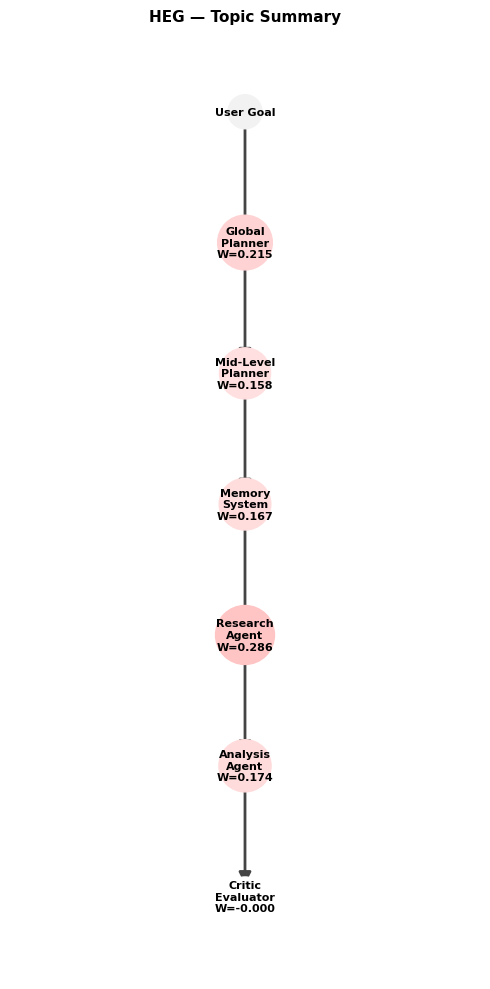

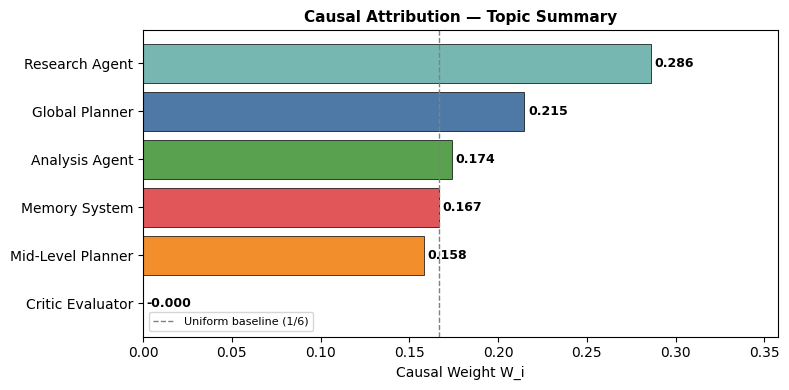

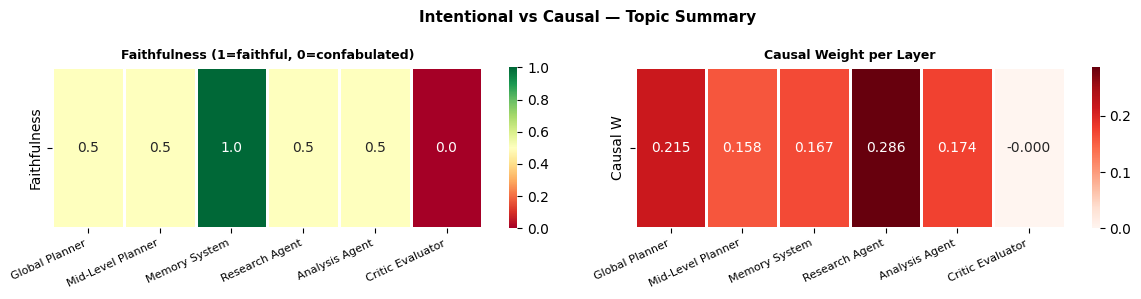

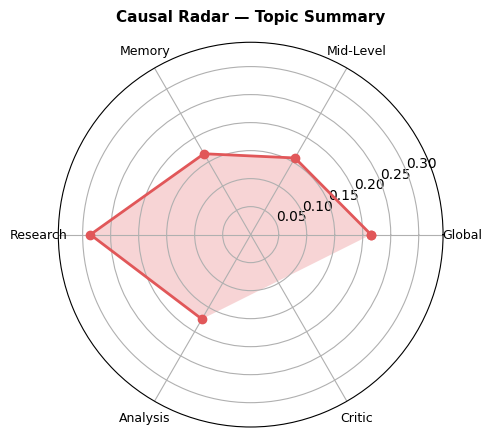


  📊 Causal weights: {'Global Planner': 0.215, 'Mid-Level Planner': 0.158, 'Memory System': 0.167, 'Research Agent': 0.286, 'Analysis Agent': 0.174, 'Critic Evaluator': -0.0}
  🔍 Faithfulness: 1 faithful | 4 partial | 1 confabulated
  ⚠️  Confabulated layers: ['Critic Evaluator']

TASK 2: Factual Q&A  [SIMPLE]
Goal: Answer the question: What are the main differences between supervised and unsupervised learning?
  🔵 Orchestrator A running...
    ✓ Global Planner
    ✓ Mid-Level Planner
    ✓ Memory System
    ✓ Research Agent
    ✓ Analysis Agent
    ✓ Critic Evaluator
  ✅ Orchestrator A complete
  🔴 Orchestrator B running...
    ✓ Perturbing Global Planner
    ✓ Perturbing Mid-Level Planner
    ✓ Perturbing Memory System
    ✓ Perturbing Research Agent
    ✓ Perturbing Analysis Agent
    ✓ Perturbing Critic Evaluator
  ✅ Orchestrator B complete


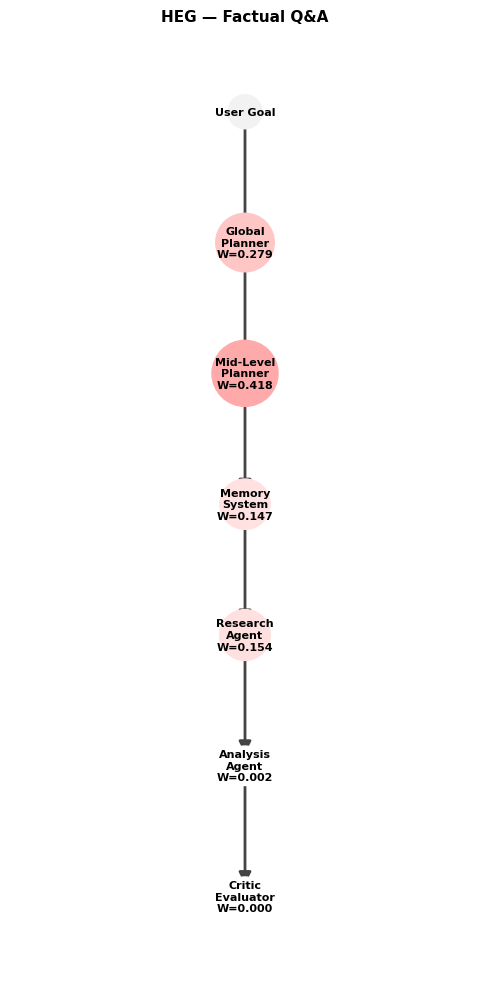

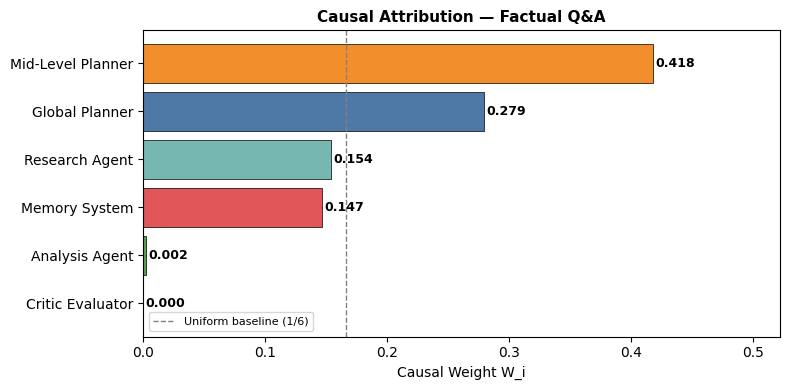

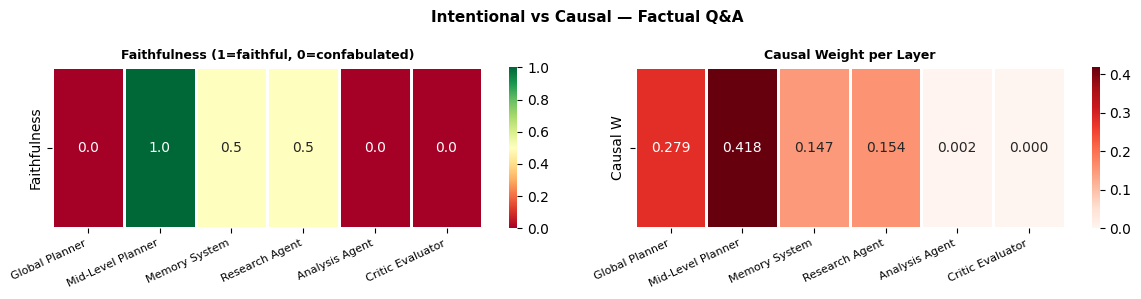

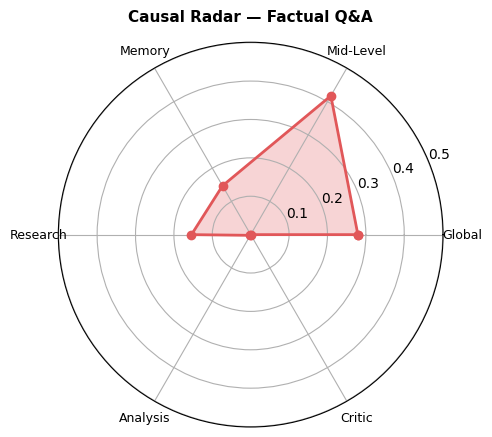


  📊 Causal weights: {'Global Planner': 0.279, 'Mid-Level Planner': 0.418, 'Memory System': 0.147, 'Research Agent': 0.154, 'Analysis Agent': 0.002, 'Critic Evaluator': 0.0}
  🔍 Faithfulness: 1 faithful | 2 partial | 3 confabulated
  ⚠️  Confabulated layers: ['Global Planner', 'Analysis Agent', 'Critic Evaluator']

TASK 3: Email Drafting  [SIMPLE]
Goal: Write a professional email to a professor requesting feedback on a research proposal
  🔵 Orchestrator A running...
    ✓ Global Planner
    ✓ Mid-Level Planner
    ✓ Memory System
    ✓ Research Agent
    ✓ Analysis Agent
    ✓ Critic Evaluator
  ✅ Orchestrator A complete
  🔴 Orchestrator B running...
    ✓ Perturbing Global Planner
    ✓ Perturbing Mid-Level Planner
    ✓ Perturbing Memory System
    ✓ Perturbing Research Agent
    ✓ Perturbing Analysis Agent
    ✓ Perturbing Critic Evaluator
  ✅ Orchestrator B complete


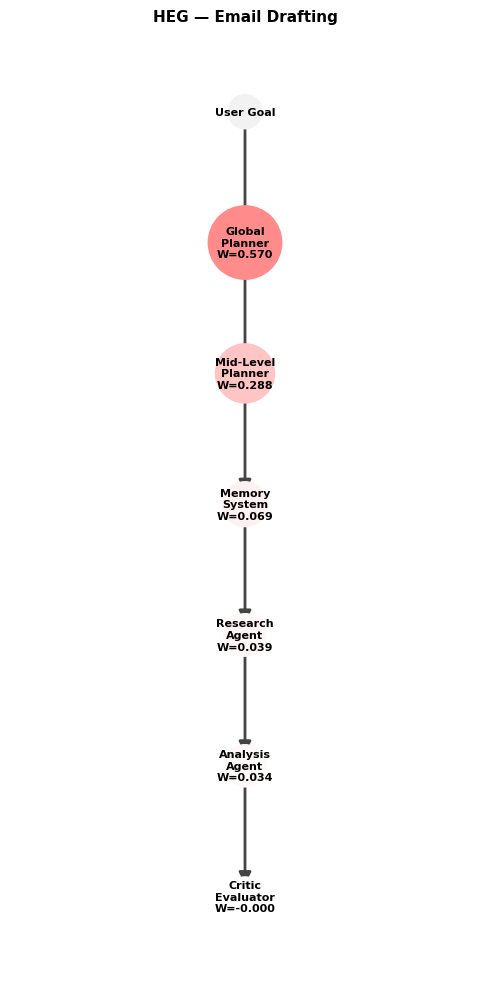

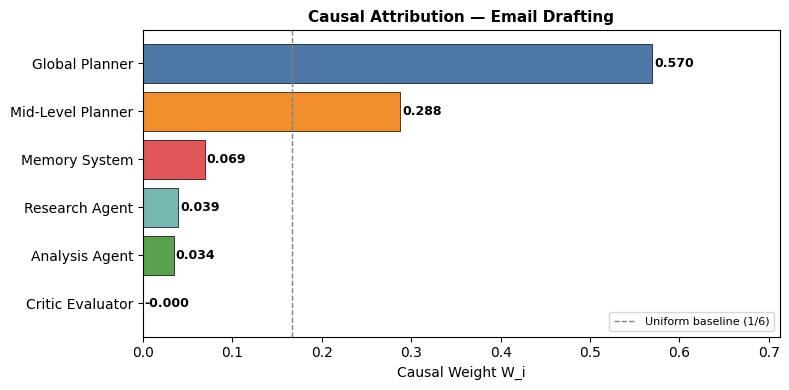

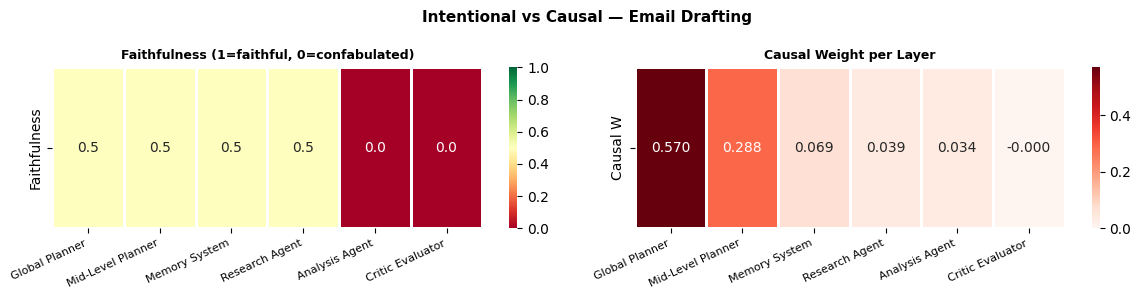

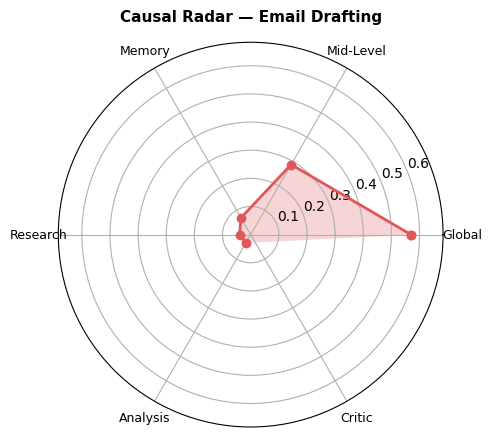


  📊 Causal weights: {'Global Planner': 0.57, 'Mid-Level Planner': 0.288, 'Memory System': 0.069, 'Research Agent': 0.039, 'Analysis Agent': 0.034, 'Critic Evaluator': -0.0}
  🔍 Faithfulness: 0 faithful | 4 partial | 2 confabulated
  ⚠️  Confabulated layers: ['Analysis Agent', 'Critic Evaluator']

TASK 4: Research Project Plan  [MULTI-STEP]
Goal: Plan a 6-month research project on explainability methods for large language models, including literature review, experiment design, implementation, and paper writing
  🔵 Orchestrator A running...
    ✓ Global Planner
    ✓ Mid-Level Planner
    ✓ Memory System
    ✓ Research Agent
    ✓ Analysis Agent
    ✓ Critic Evaluator
  ✅ Orchestrator A complete
  🔴 Orchestrator B running...
    ✓ Perturbing Global Planner
    ✓ Perturbing Mid-Level Planner
    ✓ Perturbing Memory System
    ✓ Perturbing Research Agent
    ✓ Perturbing Analysis Agent
    ✓ Perturbing Critic Evaluator
  ✅ Orchestrator B complete


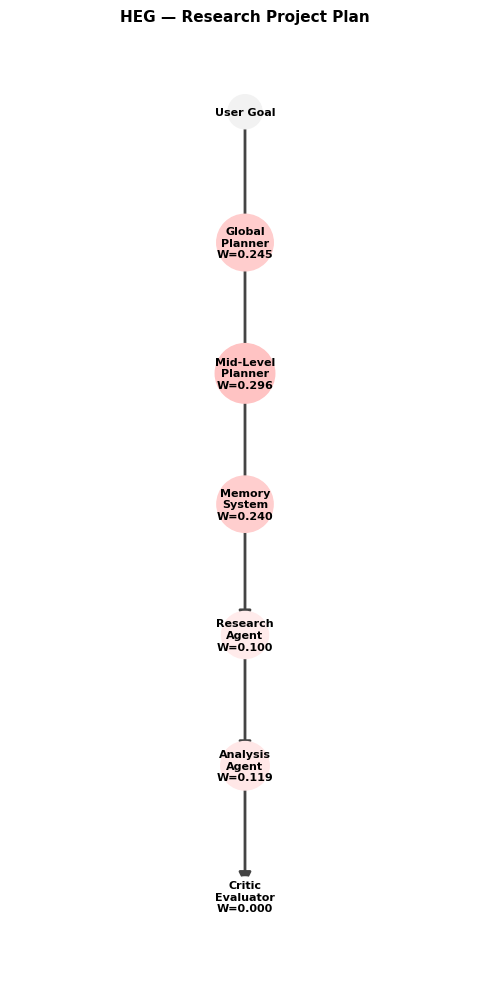

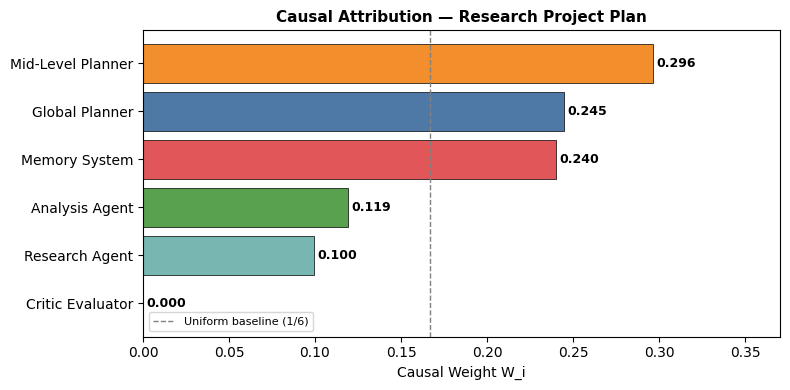

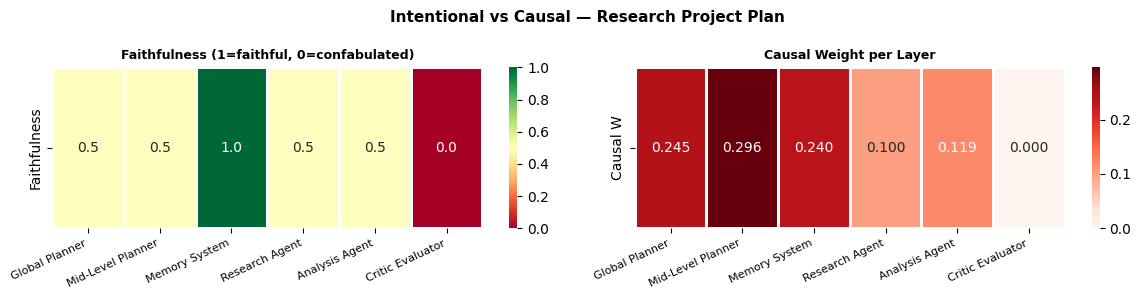

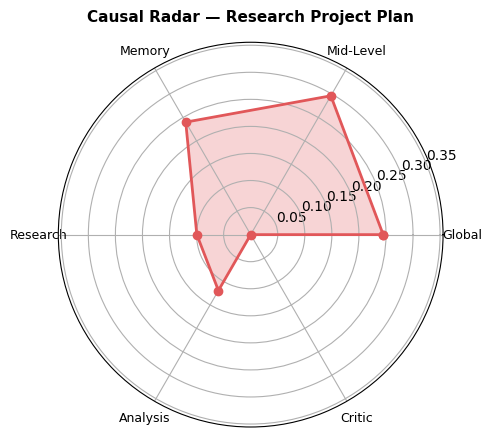


  📊 Causal weights: {'Global Planner': 0.245, 'Mid-Level Planner': 0.296, 'Memory System': 0.24, 'Research Agent': 0.1, 'Analysis Agent': 0.119, 'Critic Evaluator': 0.0}
  🔍 Faithfulness: 1 faithful | 4 partial | 1 confabulated
  ⚠️  Confabulated layers: ['Critic Evaluator']

TASK 5: System Architecture  [MULTI-STEP]
Goal: Design a scalable multi-agent AI system for automated customer support, including architecture decisions, tool integrations, fallback strategies, and deployment plan
  🔵 Orchestrator A running...
    ✓ Global Planner
    ✓ Mid-Level Planner
    ✓ Memory System
    ✓ Research Agent
    ✓ Analysis Agent
    ✓ Critic Evaluator
  ✅ Orchestrator A complete
  🔴 Orchestrator B running...
    ✓ Perturbing Global Planner
    ✓ Perturbing Mid-Level Planner
    ✓ Perturbing Memory System
    ✓ Perturbing Research Agent
    ✓ Perturbing Analysis Agent
    ✓ Perturbing Critic Evaluator
  ✅ Orchestrator B complete


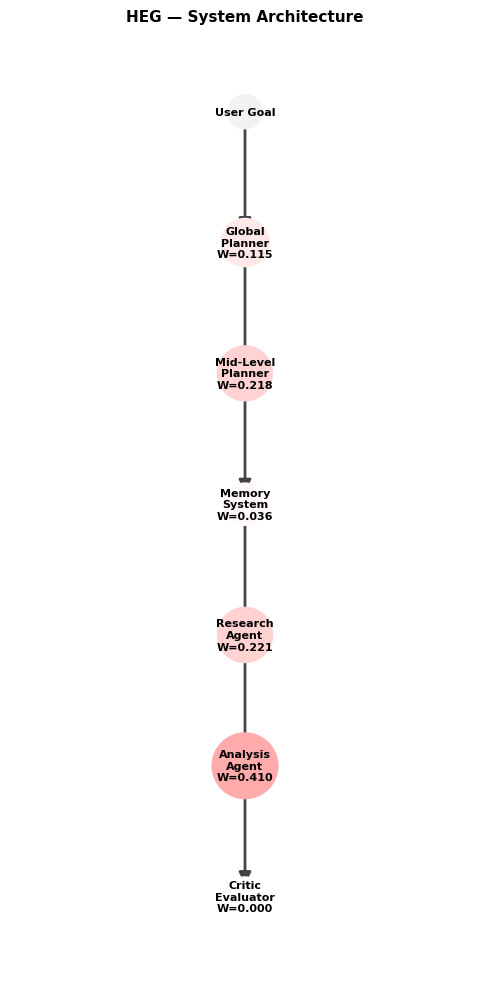

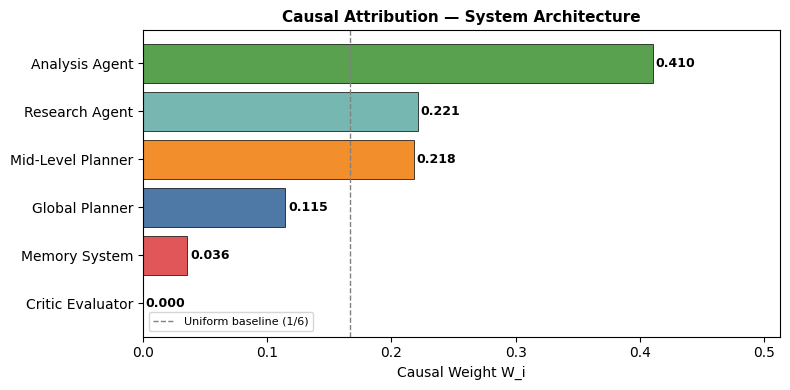

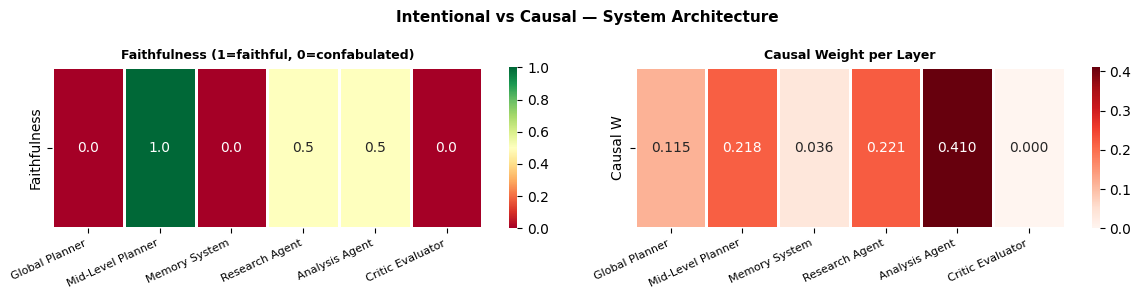

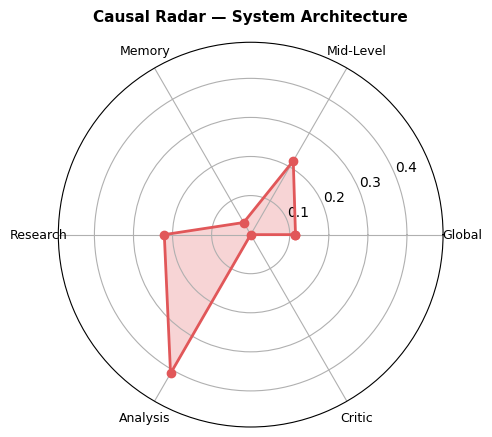


  📊 Causal weights: {'Global Planner': 0.115, 'Mid-Level Planner': 0.218, 'Memory System': 0.036, 'Research Agent': 0.221, 'Analysis Agent': 0.41, 'Critic Evaluator': 0.0}
  🔍 Faithfulness: 1 faithful | 2 partial | 3 confabulated
  ⚠️  Confabulated layers: ['Global Planner', 'Memory System', 'Critic Evaluator']

TASK 6: Literature Review  [MULTI-STEP]
Goal: Write a comprehensive literature review on reinforcement learning methods for robotics, covering model-based, model-free, and hierarchical approaches with comparisons
  🔵 Orchestrator A running...
    ✓ Global Planner
    ✓ Mid-Level Planner
    ✓ Memory System
    ✓ Research Agent
    ✓ Analysis Agent
    ✓ Critic Evaluator
  ✅ Orchestrator A complete
  🔴 Orchestrator B running...
    ✓ Perturbing Global Planner
    ✓ Perturbing Mid-Level Planner
    ✓ Perturbing Memory System
    ✓ Perturbing Research Agent
    ✓ Perturbing Analysis Agent
    ✓ Perturbing Critic Evaluator
  ✅ Orchestrator B complete


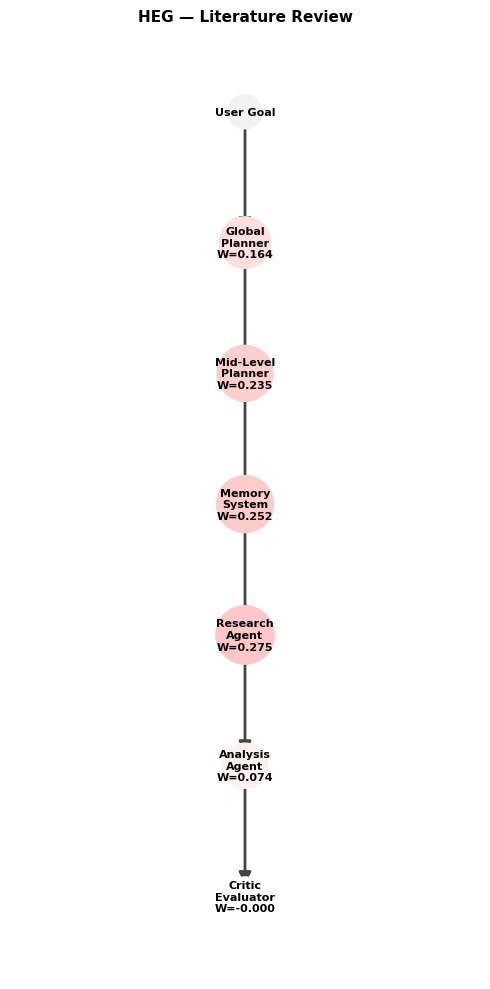

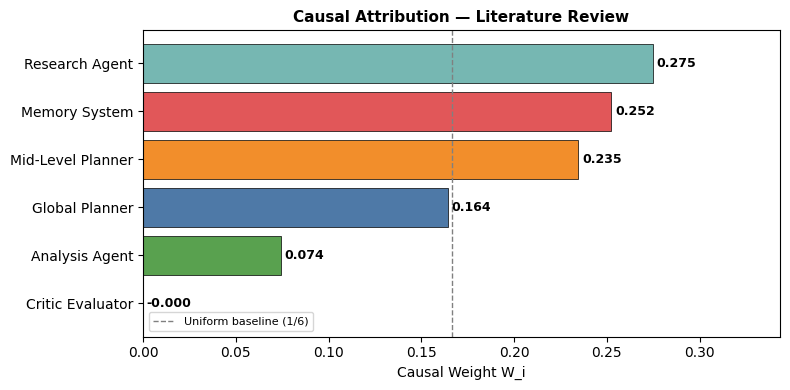

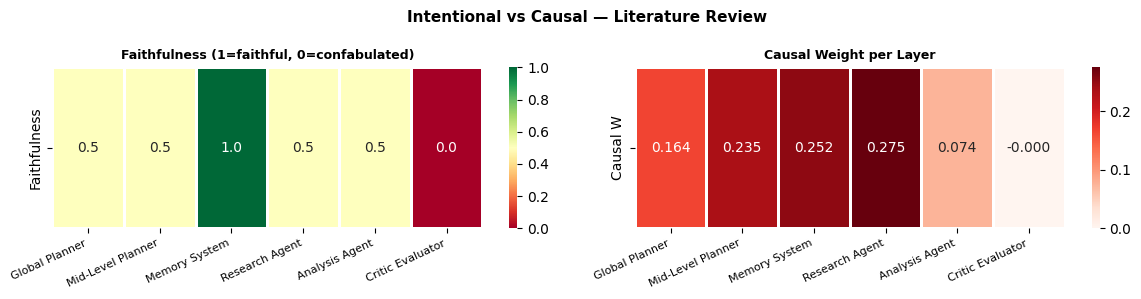

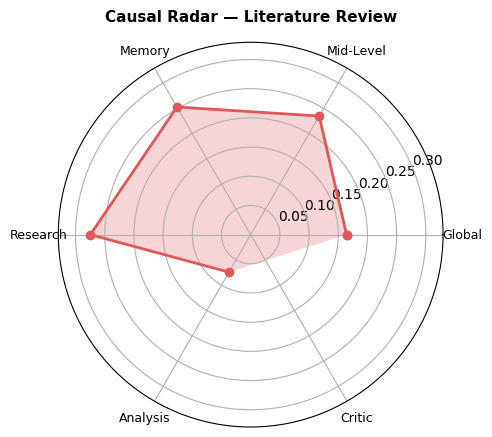


  📊 Causal weights: {'Global Planner': 0.164, 'Mid-Level Planner': 0.235, 'Memory System': 0.252, 'Research Agent': 0.275, 'Analysis Agent': 0.074, 'Critic Evaluator': -0.0}
  🔍 Faithfulness: 1 faithful | 4 partial | 1 confabulated
  ⚠️  Confabulated layers: ['Critic Evaluator']

TASK 7: Product Roadmap  [MULTI-STEP]
Goal: Design a 12-month product roadmap for an AI SaaS platform targeting SMBs, including feature prioritization, go-to-market strategy, pricing tiers, and success metrics
  🔵 Orchestrator A running...
    ✓ Global Planner
    ✓ Mid-Level Planner
    ✓ Memory System
    ✓ Research Agent
    ✓ Analysis Agent
    ✓ Critic Evaluator
  ✅ Orchestrator A complete
  🔴 Orchestrator B running...
    ✓ Perturbing Global Planner
    ✓ Perturbing Mid-Level Planner
    ✓ Perturbing Memory System
    ✓ Perturbing Research Agent
    ✓ Perturbing Analysis Agent
    ✓ Perturbing Critic Evaluator
  ✅ Orchestrator B complete


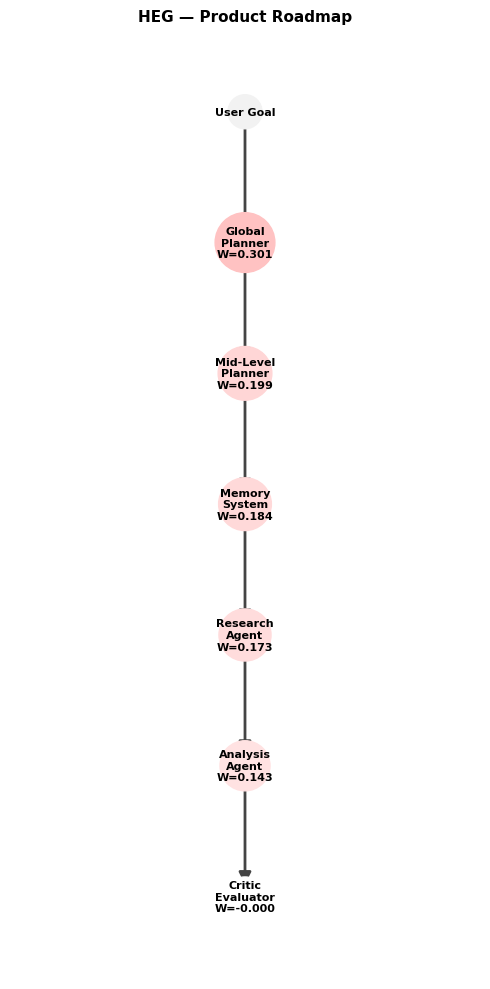

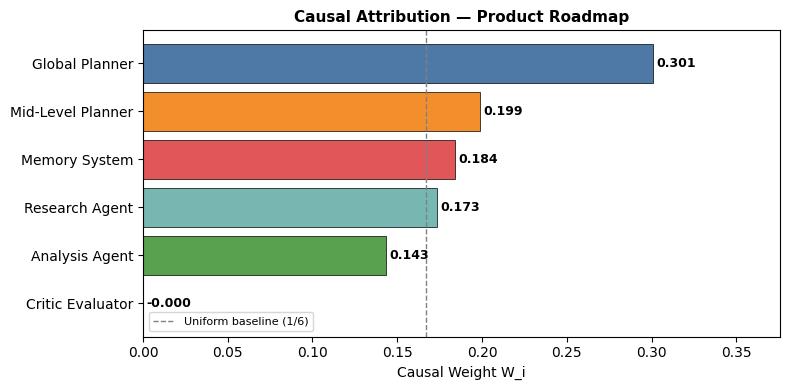

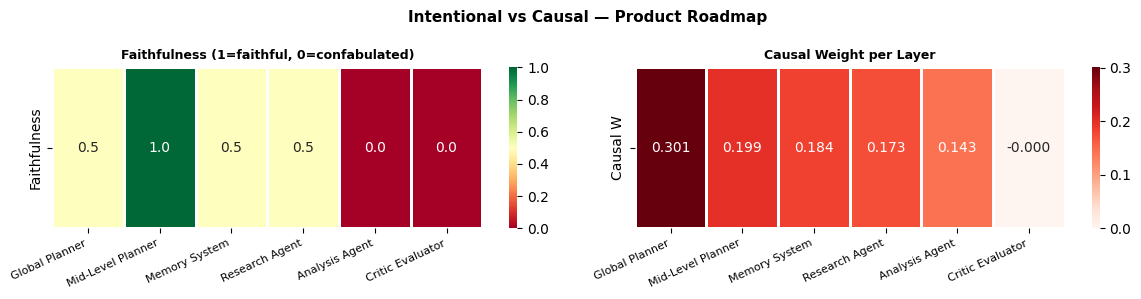

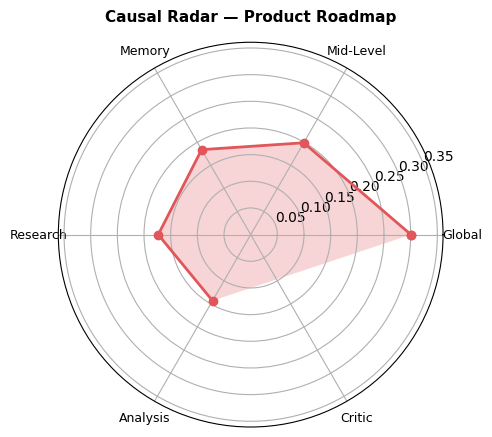


  📊 Causal weights: {'Global Planner': 0.301, 'Mid-Level Planner': 0.199, 'Memory System': 0.184, 'Research Agent': 0.173, 'Analysis Agent': 0.143, 'Critic Evaluator': -0.0}
  🔍 Faithfulness: 1 faithful | 3 partial | 2 confabulated
  ⚠️  Confabulated layers: ['Analysis Agent', 'Critic Evaluator']

✅ All 7 tasks complete


In [ ]:
TASKS = [
    # id, label, complexity, goal
    (1, "Topic Summary",        "simple",
     "Summarize the key principles of transformer neural networks in 3 bullet points"),

    (2, "Factual Q&A",          "simple",
     "Answer the question: What are the main differences between supervised and unsupervised learning?"),

    (3, "Email Drafting",       "simple",
     "Write a professional email to a professor requesting feedback on a research proposal"),

    (4, "Research Project Plan","multi-step",
     "Plan a 6-month research project on explainability methods for large language models, "
     "including literature review, experiment design, implementation, and paper writing"),

    (5, "System Architecture",  "multi-step",
     "Design a scalable multi-agent AI system for automated customer support, "
     "including architecture decisions, tool integrations, fallback strategies, and deployment plan"),

    (6, "Literature Review",    "multi-step",
     "Write a comprehensive literature review on reinforcement learning methods for robotics, "
     "covering model-based, model-free, and hierarchical approaches with comparisons"),

    (7, "Product Roadmap",      "multi-step",
     "Design a 12-month product roadmap for an AI SaaS platform targeting SMBs, "
     "including feature prioritization, go-to-market strategy, pricing tiers, and success metrics"),
]

# ── Run all tasks ──────────────────────────────────────────────────────────────
all_results = []
for task_id, task_label, complexity, goal in TASKS:
    result = run_heg_task(task_id, task_label, complexity, goal)
    all_results.append(result)

print(f"\n✅ All {len(all_results)} tasks complete") # Re-executing all tasks with updated functions.

## 12. Cross-Task Analysis

Compare causal weight distributions and faithfulness across all 7 tasks.

In [ ]:
# ── Build summary DataFrame ────────────────────────────────────────────────────
rows = []
for result in all_results:
    for exp in result.experiments:
        report = next((r for r in result.reports if r["layer"] == exp.target_layer), {})
        rows.append({
            "task_id":    result.task_id,
            "task_label": result.task_label,
            "complexity": result.complexity,
            "layer":      exp.target_layer,
            "layer_idx":  exp.target_layer_index,
            "divergence": exp.divergence,
            "causal_weight": exp.causal_weight,
            "faithfulness":  report.get("faithfulness", "unknown"),
            "discrepancy":   report.get("discrepancy_detected", False)
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

 task_id            task_label complexity             layer  layer_idx    divergence  causal_weight faithfulness  discrepancy
       1         Topic Summary     simple    Global Planner          0  1.436033e-01   2.148347e-01      partial         True
       1         Topic Summary     simple Mid-Level Planner          1  1.056503e-01   1.580560e-01      partial         True
       1         Topic Summary     simple     Memory System          2  1.114568e-01   1.667427e-01     faithful        False
       1         Topic Summary     simple    Research Agent          3  1.912972e-01   2.861862e-01      partial         True
       1         Topic Summary     simple    Analysis Agent          4  1.164286e-01   1.741806e-01      partial         True
       1         Topic Summary     simple  Critic Evaluator          5 -1.192093e-07  -1.783406e-07 confabulated         True
       2           Factual Q&A     simple    Global Planner          0  1.020133e-01   2.792376e-01 confabulated      

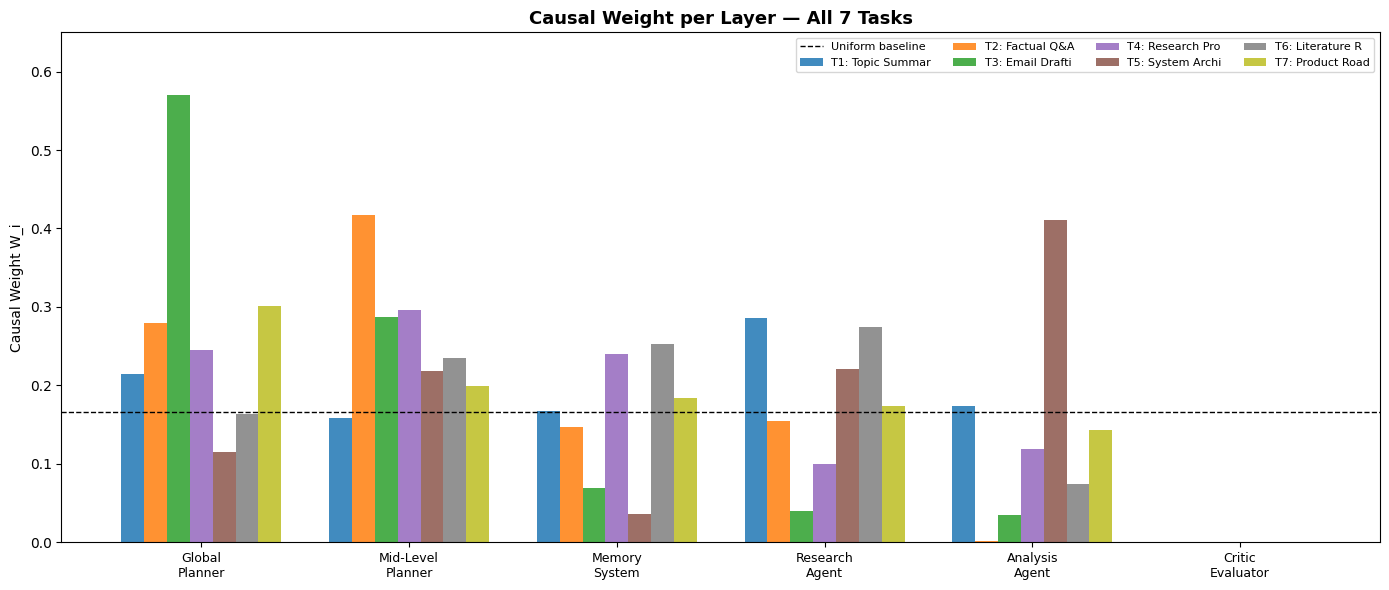

✅ Cross-task grouped bar saved


In [ ]:
# ── Plot 1: Causal weight per layer, all tasks (grouped bar) ──────────────────
fig, ax = plt.subplots(figsize=(14, 6))
layers    = df["layer"].unique()
task_ids  = sorted(df["task_id"].unique())
x         = np.arange(len(layers))
bar_width = 0.11
cmap      = plt.cm.tab10

for i, tid in enumerate(task_ids):
    sub = df[df["task_id"] == tid].sort_values("layer_idx")
    vals = sub["causal_weight"].values
    label = f"T{tid}: {all_results[tid-1].task_label[:12]}"
    ax.bar(x + i*bar_width, vals, bar_width, label=label, color=cmap(i/len(task_ids)), alpha=0.85)

ax.set_xticks(x + bar_width*(len(task_ids)-1)/2)
ax.set_xticklabels([l.replace(" ", "\n") for l in layers], fontsize=9)
ax.axhline(1/6, color="black", ls="--", lw=1, label="Uniform baseline")
ax.set_ylabel("Causal Weight W_i"); ax.set_ylim(0, 0.65)
ax.set_title("Causal Weight per Layer — All 7 Tasks", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, ncol=4, loc="upper right")
plt.tight_layout()
plt.savefig("heg_outputs/cross_task_grouped_bar.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Cross-task grouped bar saved")

/tmp/ipykernel_612/726282538.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace(" ", "\n") for l in mean_w.index], fontsize=9)
/tmp/ipykernel_612/726282538.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace(" ", "\n") for l in mean_w.index], fontsize=9)


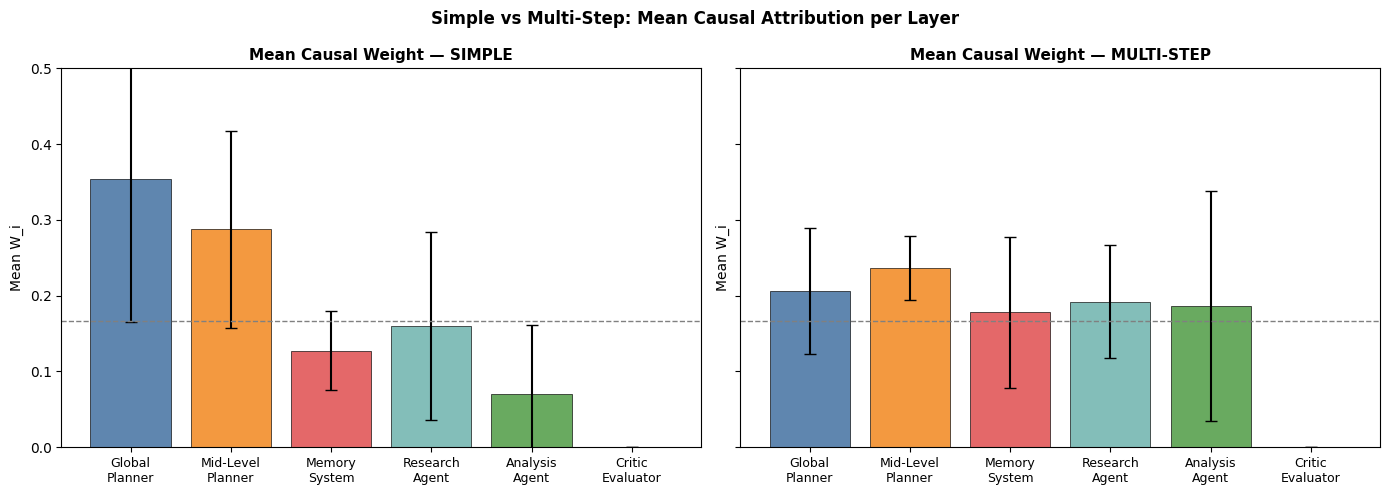

✅ Simple vs multi-step comparison saved


In [ ]:
# ── Plot 2: Mean causal weight per layer (simple vs multi-step) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, comp in zip(axes, ["simple", "multi-step"]):
    sub = df[df["complexity"] == comp]
    mean_w = sub.groupby("layer")["causal_weight"].mean().reindex(
        df.sort_values("layer_idx")["layer"].unique()
    )
    std_w = sub.groupby("layer")["causal_weight"].std().reindex(mean_w.index).fillna(0)
    colors = [LAYER_COLORS[i] for i in range(len(mean_w))]
    bars = ax.bar(mean_w.index, mean_w.values, yerr=std_w.values,
                  color=colors, edgecolor="black", lw=0.5, capsize=4, alpha=0.9)
    ax.axhline(1/6, color="gray", ls="--", lw=1)
    ax.set_xticklabels([l.replace(" ", "\n") for l in mean_w.index], fontsize=9)
    ax.set_title(f"Mean Causal Weight — {comp.upper()}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Mean W_i")
    ax.set_ylim(0, 0.5)

plt.suptitle("Simple vs Multi-Step: Mean Causal Attribution per Layer", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("heg_outputs/cross_simple_vs_multistep.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Simple vs multi-step comparison saved")

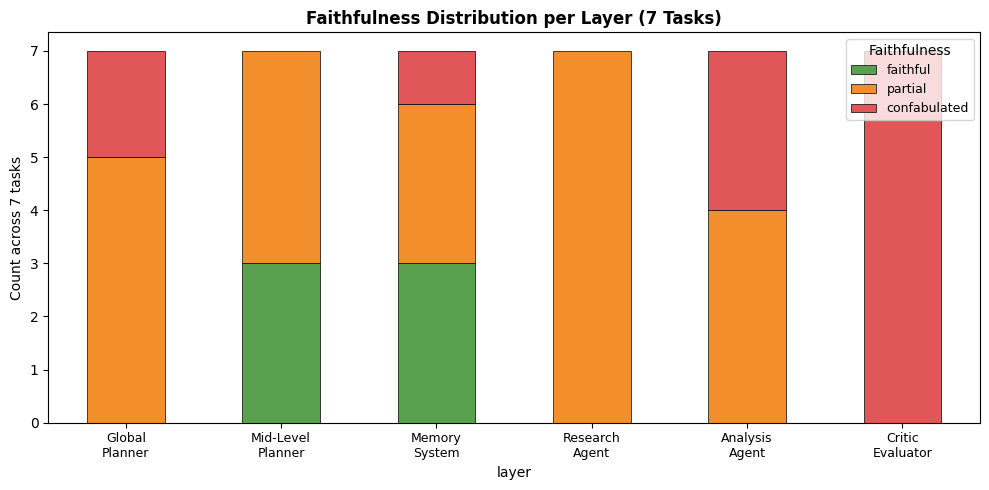

✅ Faithfulness stacked bar saved


In [ ]:
# ── Plot 3: Faithfulness distribution across all tasks ────────────────────────
faith_map = {"faithful": 2, "partial": 1, "confabulated": 0}
df["faith_score"] = df["faithfulness"].map(faith_map)

# Stacked bar: faithfulness counts per layer
pivot = df.groupby(["layer","faithfulness"]).size().unstack(fill_value=0)
pivot = pivot.reindex(df.sort_values("layer_idx")["layer"].unique())
for col in ["faithful","partial","confabulated"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["faithful","partial","confabulated"]]

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", stacked=True, ax=ax,
           color=["#59a14f","#f28e2b","#e15759"], edgecolor="black", lw=0.5)
ax.set_xticklabels([l.replace(" ", "\n") for l in pivot.index], rotation=0, fontsize=9)
ax.set_ylabel("Count across 7 tasks")
ax.set_title("Faithfulness Distribution per Layer (7 Tasks)", fontsize=12, fontweight="bold")
ax.legend(title="Faithfulness", fontsize=9)
plt.tight_layout()
plt.savefig("heg_outputs/cross_faithfulness_stacked.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Faithfulness stacked bar saved")

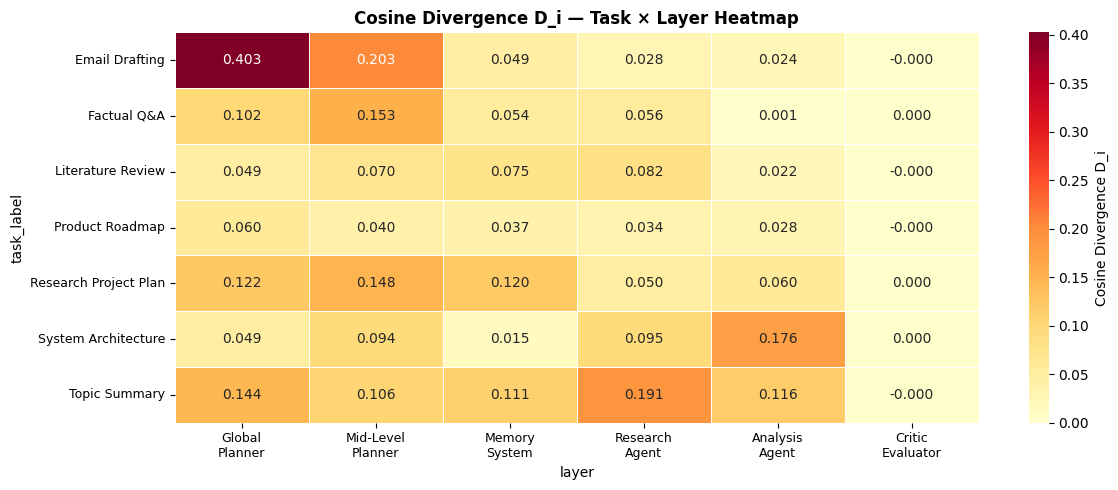

✅ Divergence heatmap saved


In [ ]:
# ── Plot 4: Divergence heatmap (task × layer) ─────────────────────────────────
pivot_div = df.pivot_table(index="task_label", columns="layer", values="divergence")
# reorder columns by layer index
col_order = df.drop_duplicates("layer").sort_values("layer_idx")["layer"].tolist()
pivot_div = pivot_div[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_div, ax=ax, cmap="YlOrRd", annot=True, fmt=".3f",
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Cosine Divergence D_i"})
ax.set_xticklabels([c.replace(" ", "\n") for c in pivot_div.columns], fontsize=9)
ax.set_yticklabels(pivot_div.index, fontsize=9, rotation=0)
ax.set_title("Cosine Divergence D_i — Task × Layer Heatmap", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("heg_outputs/cross_divergence_heatmap.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Divergence heatmap saved")

/tmp/ipykernel_612/1315930151.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dominant["task_label"], rotation=20, ha="right", fontsize=9)


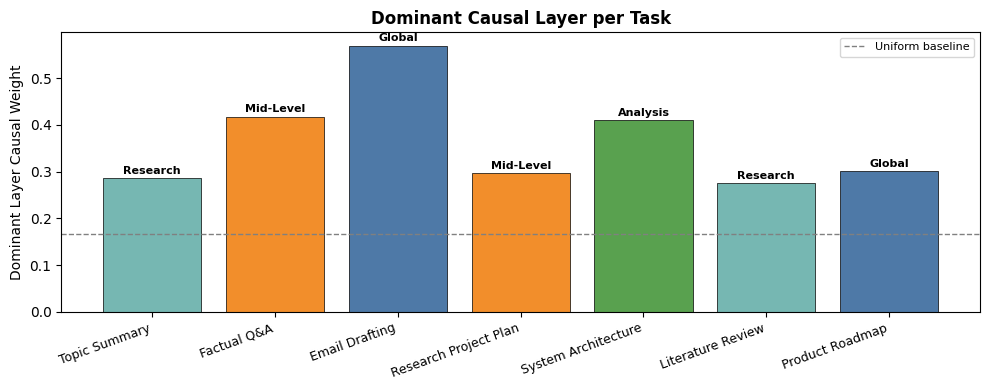

✅ Dominant layer chart saved
 task_id            task_label complexity             layer  causal_weight
       1         Topic Summary     simple    Research Agent       0.286186
       2           Factual Q&A     simple Mid-Level Planner       0.417595
       3        Email Drafting     simple    Global Planner       0.569659
       4 Research Project Plan multi-step Mid-Level Planner       0.296247
       5   System Architecture multi-step    Analysis Agent       0.410333
       6     Literature Review multi-step    Research Agent       0.274611
       7       Product Roadmap multi-step    Global Planner       0.300618


In [ ]:
# ── Plot 5: Dominant layer per task ───────────────────────────────────────────
dominant = df.loc[df.groupby("task_id")["causal_weight"].idxmax()][["task_id","task_label","complexity","layer","causal_weight"]]

fig, ax = plt.subplots(figsize=(10, 4))
colors_dom = [LAYER_COLORS[df[df["layer"]==row.layer]["layer_idx"].iloc[0]] for _, row in dominant.iterrows()]
bars = ax.bar(dominant["task_label"], dominant["causal_weight"], color=colors_dom, edgecolor="black", lw=0.5)
for bar, (_, row) in zip(bars, dominant.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            row["layer"].split()[0], ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_ylabel("Dominant Layer Causal Weight")
ax.set_xticklabels(dominant["task_label"], rotation=20, ha="right", fontsize=9)
ax.set_title("Dominant Causal Layer per Task", fontsize=12, fontweight="bold")
ax.axhline(1/6, color="gray", ls="--", lw=1, label="Uniform baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("heg_outputs/cross_dominant_layer.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Dominant layer chart saved")
print(dominant.to_string(index=False))

/tmp/ipykernel_612/314450985.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  confab_rate = df.groupby("layer").apply(
/tmp/ipykernel_612/314450985.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace(" ", "\n") for l in confab_rate.index], fontsize=9)


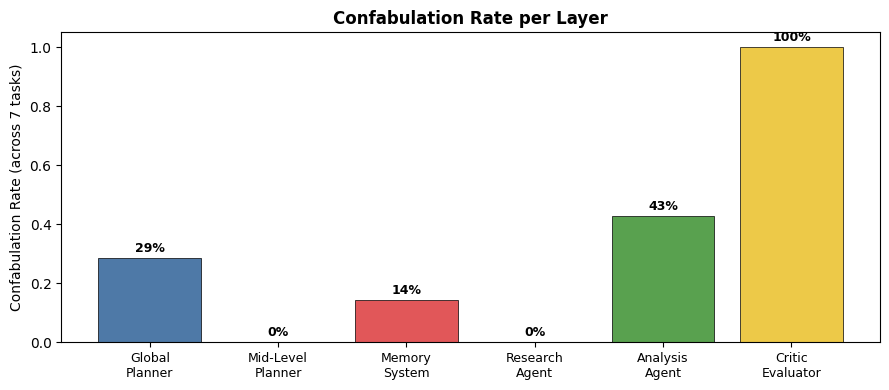

✅ Confabulation rate chart saved


In [ ]:
# ── Plot 6: Confabulation rate per layer ──────────────────────────────────────
confab_rate = df.groupby("layer").apply(
    lambda x: (x["faithfulness"] == "confabulated").sum() / len(x)
).reindex(col_order)

fig, ax = plt.subplots(figsize=(9, 4))
colors_c = [LAYER_COLORS[i] for i in range(len(confab_rate))]
ax.bar(confab_rate.index, confab_rate.values, color=colors_c, edgecolor="black", lw=0.5)
ax.set_xticklabels([l.replace(" ", "\n") for l in confab_rate.index], fontsize=9)
ax.set_ylabel("Confabulation Rate (across 7 tasks)")
ax.set_ylim(0, 1.05)
ax.set_title("Confabulation Rate per Layer", fontsize=12, fontweight="bold")
for i, (layer, val) in enumerate(confab_rate.items()):
    ax.text(i, val+0.02, f"{val:.0%}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("heg_outputs/cross_confabulation_rate.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Confabulation rate chart saved")

/tmp/ipykernel_612/1561185033.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(task_total_div["task_label"], rotation=20, ha="right", fontsize=9)


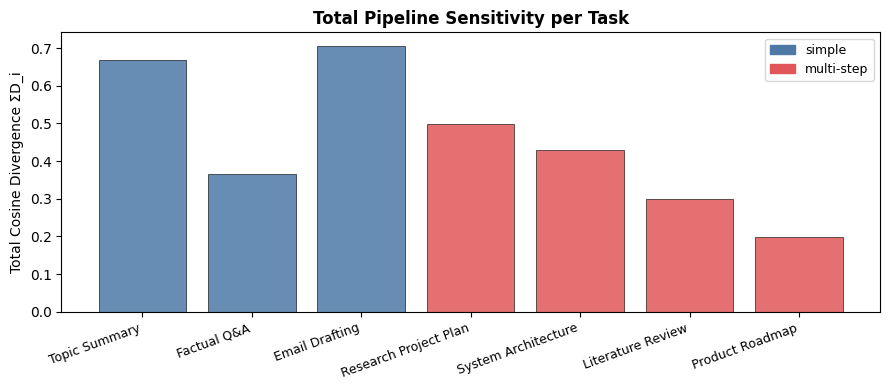

✅ Total divergence chart saved


In [ ]:
# ── Plot 7: Complexity vs total divergence ────────────────────────────────────
task_total_div = df.groupby(["task_id","task_label","complexity"])["divergence"].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
colors_cplx = {"simple": "#4e79a7", "multi-step": "#e15759"}
for _, row in task_total_div.iterrows():
    ax.bar(row["task_label"], row["divergence"],
           color=colors_cplx[row["complexity"]], edgecolor="black", lw=0.5, alpha=0.85)

ax.set_xticklabels(task_total_div["task_label"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Total Cosine Divergence ΣD_i")
ax.set_title("Total Pipeline Sensitivity per Task", fontsize=12, fontweight="bold")
patches = [mpatches.Patch(color=v, label=k) for k, v in colors_cplx.items()]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig("heg_outputs/cross_total_divergence.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Total divergence chart saved")

## 13. Final Summary Table

In [ ]:
summary_rows = []
for result in all_results:
    top_layer = max(result.experiments, key=lambda e: e.causal_weight)
    confab_count = sum(1 for r in result.reports if r["faithfulness"] == "confabulated")
    partial_count = sum(1 for r in result.reports if r["faithfulness"] == "partial")
    faith_count = len(result.reports) - confab_count - partial_count
    summary_rows.append({
        "Task": f"T{result.task_id}: {result.task_label}",
        "Complexity": result.complexity,
        "Dominant Layer": top_layer.target_layer,
        "Dominant W": round(top_layer.causal_weight, 3),
        "Faithful": faith_count,
        "Partial": partial_count,
        "Confabulated": confab_count,
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*75)
print("FULL EXPERIMENT SUMMARY — HEG FRAMEWORK (7 Tasks)")
print("="*75)
print(summary_df.to_string(index=False))
print("="*75)
summary_df


FULL EXPERIMENT SUMMARY — HEG FRAMEWORK (7 Tasks)
                     Task Complexity    Dominant Layer  Dominant W  Faithful  Partial  Confabulated
        T1: Topic Summary     simple    Research Agent       0.286         1        4             1
          T2: Factual Q&A     simple Mid-Level Planner       0.418         1        2             3
       T3: Email Drafting     simple    Global Planner       0.570         0        4             2
T4: Research Project Plan multi-step Mid-Level Planner       0.296         1        4             1
  T5: System Architecture multi-step    Analysis Agent       0.410         1        2             3
    T6: Literature Review multi-step    Research Agent       0.275         1        4             1
      T7: Product Roadmap multi-step    Global Planner       0.301         1        3             2


,Task,Complexity,Dominant Layer,Dominant W,Faithful,Partial,Confabulated
0,T1: Topic Summary,simple,Research Agent,0.286,1,4,1
1,T2: Factual Q&A,simple,Mid-Level Planner,0.418,1,2,3
2,T3: Email Drafting,simple,Global Planner,0.570,0,4,2
3,T4: Research Project Plan,multi-step,Mid-Level Planner,0.296,1,4,1
4,T5: System Architecture,multi-step,Analysis Agent,0.410,1,2,3
5,T6: Literature Review,multi-step,Research Agent,0.275,1,4,1
6,T7: Product Roadmap,multi-step,Global Planner,0.301,1,3,2


In [ ]:
import os
from google.colab import drive
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# Define source and destination paths
source_dir = '/content/heg_outputs'
dest_dir = '/content/drive/MyDrive/heg_outputs_backup'

# Create the destination directory if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# Copy contents of source_dir to dest_dir
# Use copytree if the destination does not exist, otherwise iterate and copy
if os.path.exists(source_dir):
    for item in os.listdir(source_dir):
        s = os.path.join(source_dir, item)
        d = os.path.join(dest_dir, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)
    print(f"✅ Successfully copied '{source_dir}' to '{dest_dir}'")
else:
    print(f"❌ Source directory '{source_dir}' does not exist.")

Mounted at /content/drive
✅ Successfully copied '/content/heg_outputs' to '/content/drive/MyDrive/heg_outputs_backup'
